In [1]:
import beaker
import io
import string
import textwrap

import cartopy.crs as ccrs
import dask.diagnostics
import faceted
import numpy as np
import pandas as pd
import xarray as xr

from upath import UPath

import plotting

In [2]:
ROOT = UPath(
    "gs://vcm-ml-intermediate/2025-02-07-vertically-resolved-1deg-c96-shield-som-abrupt-4xCO2-ensemble-fme-dataset"
)

In [3]:
def open_beaker_dataset(dataset_id: str, path: str, variables=None) -> xr.Dataset:
    """Given a beaker dataset ID and path within dataset, return an xarray
    dataset.

    Note: dataset must fit in memory. Requires h5netcdf backend.  Adapted from
    ace2-paper repo.
    """
    client = beaker.Beaker.from_env()
    file = client.dataset.get_file(dataset_id, path)
    if variables is None:
        ds = xr.open_dataset(io.BytesIO(file), engine="h5netcdf").load()
    else:
        ds = xr.open_dataset(io.BytesIO(file), engine="h5netcdf")[variables].load()
    if "source" not in ds.dims:
        ds = ds.expand_dims(source=["target", "prediction"])
    rename = {v: v.replace("gen_map-", "") for v in ds}
    return ds.rename(rename)

In [4]:
SHORT_ACE_4xCO2_RUNS = {
    "ACE2-SOM baseline": "01KJ5PWY865SN4J1K5GHKFERT2",
    "no-random-co2 non-energy-conserving rs0": "01KJ5PZ0CR5ZSZ3MXKG45KQ2ES",
    "no-random-co2 non-energy-conserving rs1": "01KJ5PYQT3WNAY22A609EV6VWN",
    "no-random-co2 energy-conserving rs0": "01KJ5PXZRPMCYBDGRBQ9851PBK",
    "no-random-co2 energy-conserving rs1": "01KJ5PXQ4NE64SFPA6YPRVNBW5",
    "full non-energy-conserving rs0": "01KJ5PX6HP06A4T75VSA7XNVJR",
    "full non-energy-conserving rs1": "01KJ5PXFPJARXQ78C8BJN91WYG",
    "full energy-conserving rs0": "01KJ5PY7HS6CNC814WEVQH4NN5",
    "full energy-conserving rs1": "01KJ5PYFBVM3QH5YPS32Z66PQ3",
    "residual-predicting energy-conserving multi-call rs0": "01KJANNWGRADNE5BATHKVP30PN",
}
SHORT_ACE_1xCO2_RUNS = {    
    "ACE2-SOM baseline": "01KJ5PTTFAPP5JV0813Z11T9SB",
    "no-random-co2 non-energy-conserving rs0": "01KJ5PWPC61VJZECBCSNBRGSNG",
    "no-random-co2 non-energy-conserving rs1": "01KJ5PWEP8Q6R6AN9R3YBZ4TRN",
    "no-random-co2 energy-conserving rs0": "01KJ5PVQPFADEJZ7MC6J5EA49C",
    "no-random-co2 energy-conserving rs1": "01KJ5PVGMCZW46M812PCD46PS7",
    "full non-energy-conserving rs0": "01KJ5PV1NRMT2W6ZQWE8C1PAMT",
    "full non-energy-conserving rs1": "01KJ5Q3HE938WST4BQCH08S3ZC",
    "full energy-conserving rs0": "01KJ5PVZG4Q0WM3GFQH6VP9PJM",
    "full energy-conserving rs1": "01KJ5PW761HDYQT0M6BPA57709", 
    "residual-predicting energy-conserving multi-call rs0": "01KJANNN6YF5W3QA656JQ08WAT",
}

In [5]:
def open_shield_ensemble(root, n_members, timesteps):
    datasets = {}
    for member in range(1, n_members + 1):
        path = str(root / f"abrupt4xCO2-ic_{member:04d}.zarr")
        datasets[member] = (
            xr.open_zarr(path).isel(time=slice(None, timesteps)).mean("time")
        )
    result = xr.concat(
        datasets.values(), dim=pd.Index(datasets.keys(), name="member")
    ).mean("member")
    return result.rename({"grid_xt": "lon", "grid_yt": "lat"}).drop_vars(["lon", "lat"])


def open_shield_1xCO2_ensemble(spinup_path, member_path, timesteps, variables):
    spinup = xr.open_zarr(spinup_path)
    member = xr.open_zarr(member_path)
    ds = xr.concat([spinup, member], dim="time")[variables]
    start_times = xr.date_range("2031-01-01T06:00:00", freq="MS", periods=36)
    stop_times = start_times + (timesteps - 1) * pd.Timedelta(
        hours=6
    )  # label-based indexing is inclusive
    members = []
    for start, stop in zip(start_times, stop_times):
        subset = ds.sel(time=slice(start, stop))
        members.append(subset.mean("time"))
    return (
        xr.concat(members, dim="member")
        .mean("member")
        .rename({"grid_xt": "lon", "grid_yt": "lat"})
    )

In [6]:
TIMESTEPS = 28
shield_abrupt4xCO2 = open_shield_ensemble(ROOT, 36, TIMESTEPS)

In [7]:
spinup_path = "gs://vcm-ml-intermediate/2024-08-15-vertically-resolved-1deg-c96-shield-som-ensemble-spin-up-fme-dataset/1xCO2-spin-up-ic_0005.zarr"
member_path = "gs://vcm-ml-intermediate/2026-01-28-vertically-resolved-1deg-c96-shield-som-ensemble-fme-dataset/1xCO2-ic_0005.zarr"
shield_1xCO2 = open_shield_1xCO2_ensemble(
    spinup_path, member_path, TIMESTEPS, ["USWRFtoa", "ULWRFtoa", "LHTFLsfc", "PRATEsfc", "DSWRFsfc", "USWRFsfc"]
)

/tmp/ipykernel_5936/575063628.py:17: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.concat([spinup, member], dim="time")[variables]


In [8]:
with dask.diagnostics.ProgressBar():
    shield_response = (
        (shield_abrupt4xCO2 - shield_1xCO2).compute().assign_coords(case=["SHiELD"])
    )

[########################################] | 100% Completed | 308.02 s


In [9]:
ace_abrupt4xCO2_datasets = {}
for case, dataset_id in SHORT_ACE_4xCO2_RUNS.items():
    ace_abrupt4xCO2_datasets[case] = open_beaker_dataset(
        dataset_id, "time_mean_diagnostics.nc"
    ).sel(source="prediction")
ace_abrupt4xCO2 = xr.concat(
    ace_abrupt4xCO2_datasets.values(),
    dim="case").assign_coords(case=list(ace_abrupt4xCO2_datasets.keys()))

ace_1xCO2_datasets = {}
for case, dataset_id in SHORT_ACE_1xCO2_RUNS.items():
    ace_1xCO2_datasets[case] = open_beaker_dataset(
        dataset_id, "time_mean_diagnostics.nc"
    ).sel(source="prediction")
ace_1xCO2 = xr.concat(
    ace_1xCO2_datasets.values(), dim="case").assign_coords(case=list(ace_1xCO2_datasets.keys()))

/home/spencerc/ace2s-shield-plus-paper/manuscript/.pixi/envs/default/lib/python3.13/site-packages/beaker/util.py:25: RuntimeWarning: Found unknown field 'budget: 01HPM52AQCRXMD5BPZAMJG3TDZ' for data model 'Workspace'. This may be a newly added field that hasn't been defined in beaker-py yet. Please submit an issue report about this here:
https://github.com/allenai/beaker-py/issues/new?assignees=&labels=bug&template=bug_report.yml
  warnings.warn(
/home/spencerc/ace2s-shield-plus-paper/manuscript/.pixi/envs/default/lib/python3.13/site-packages/beaker/client.py:163: UserWarning: You're using beaker-py v1.32.2, but a newer version (v1.38.1) is available.

Please upgrade with `pip install --upgrade beaker-py`.

You can find the release notes for v1.38.1 at https://github.com/allenai/beaker-py/releases/tag/v1.38.1

  warnings.warn(
/home/spencerc/ace2s-shield-plus-paper/manuscript/.pixi/envs/default/lib/python3.13/site-packages/beaker/util.py:25: RuntimeWarning: Found unknown field 'budget:

Output()

Output()

Output()

Output()

...

Output()

Output()

Output()

Output()

Output()

In [10]:
ace_response = (ace_abrupt4xCO2 - ace_1xCO2).compute()
response = xr.concat(
    [shield_response, ace_response.drop_vars(["lat", "lon"])], dim="case"
)
response_bias = response.drop_sel(case="SHiELD") - response.sel(case="SHiELD")


In [11]:
aspect_ratio = plotting.get_aspect_ratio(ccrs.Robinson(), (-180, 180, -89.84, 89.84))

-17005833.330525298 17005833.330525298 -8624895.120045524 8624895.120045524


In [12]:
MODELS = ["SHiELD", "ACE2-SOM baseline", "no-random-co2 energy-conserving rs0", "full energy-conserving rs0"]
LABELS = {
    "SHiELD": "SHiELD-SOM",
    "ACE2-SOM baseline": "ACE2-SOM",
    "no-random-co2 energy-conserving rs0": "ACE2S-SHiELD+ w/o random CO$_2$ w/ energy conservation",
    "full energy-conserving rs0": "ACE2S-SHiELD+ w/ random CO$_2$ w/ energy conservation",
}

In [19]:
plotting.configure_style()

def plot_response(response, models, variable, long_name, units, scale_factor=1.0, vmin=-15, vmax=15):
    fig, axes, (cax1, cax2) = faceted.faceted(
        4, 
        2, 
        aspect=aspect_ratio, 
        width=5.5,
        cbar_pad=0.125,
        internal_pad=0.25,
        cbar_mode="edge", 
        cbar_location="bottom", 
        axes_kwargs={"projection": ccrs.Robinson()},
        left_pad=0.6,
        bottom_pad=0.9,
    )

    cmap = "RdBu_r"
    response = scale_factor * response[variable]
    response_bias = response.drop_sel(case="SHiELD") - response.sel(case="SHiELD")

    weights = np.cos(np.deg2rad(response.lat))
    mean = response.weighted(weights).mean(["lat", "lon"]).compute()
    rmse = np.sqrt((response_bias ** 2).weighted(weights).mean(["lat", "lon"])).compute()

    for ax, case in zip(axes[::2], models):
        p1 = response.sel(case=case).plot(
            ax=ax,
            add_colorbar=False,
            vmin=vmin,
            vmax=vmax,
            cmap=cmap,
            transform=ccrs.PlateCarree(),
        )
        ax.coastlines()
        ax.set_title(f"Global mean = {mean.sel(case=case).item():0.2f} {units}")

        ax.annotate(
            textwrap.fill(LABELS[case], 20),
            xy=(0, 0.5),
            xytext=(-17, 0),
            xycoords="axes fraction",
            textcoords="offset points",
            ha="center",
            va="center",
            rotation=90,
        )

    for ax, case in zip(axes[3::2], MODELS[1:]):
        p2 = response_bias.sel(case=case).plot(
            ax=ax,
            add_colorbar=False,
            vmin=vmin,
            vmax=vmax,
            cmap=cmap,
            transform=ccrs.PlateCarree(),
        )
        ax.coastlines()
        ax.set_title(f"Global RMSE = {rmse.sel(case=case).item():0.2f} {units}")

    for ax, label in zip(axes[::2] + axes[3::2], string.ascii_lowercase):
        ax.annotate(
            f"({label})",
            xy=(0, 1),
            xytext=(2, -2),
            va="top",
            xycoords="axes fraction",
            textcoords="offset points",
        )

    axes[1].set_visible(False)
    label = textwrap.fill(f"Initial seven-day {long_name} response to abrupt 4xCO$_2$ (abrupt 4xCO$_2$ minus 1xCO$_2$, averaged over 36 ensemble members) [{units}]", 40)
    fig.colorbar(p1, cax=cax1, orientation="horizontal", label=label)
    fig.colorbar(p2, cax=cax2, orientation="horizontal", label="Bias (ACE minus SHiELD-SOM) [W/m$^2$]")
    fig.patch.set_alpha(0.0)
    fig.savefig(f"figure-10-{variable}.png", dpi=200)
    fig.savefig(f"figure-10-{variable}.pdf")



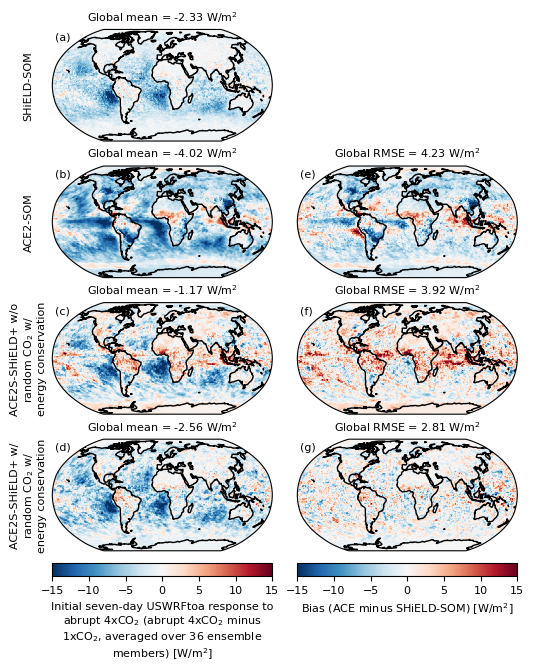

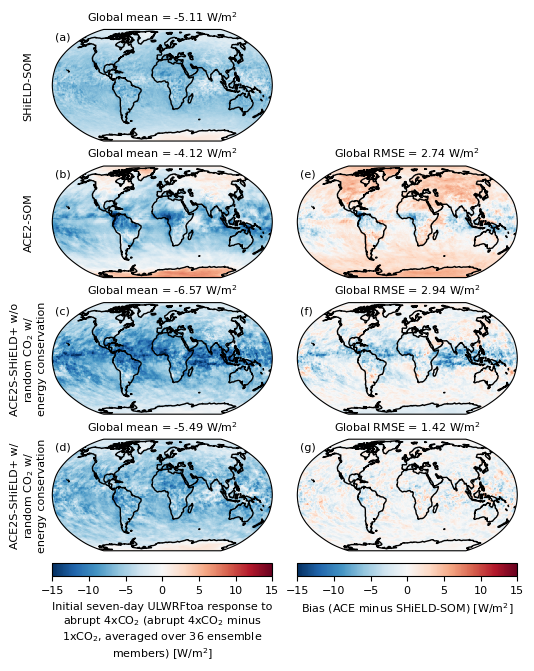

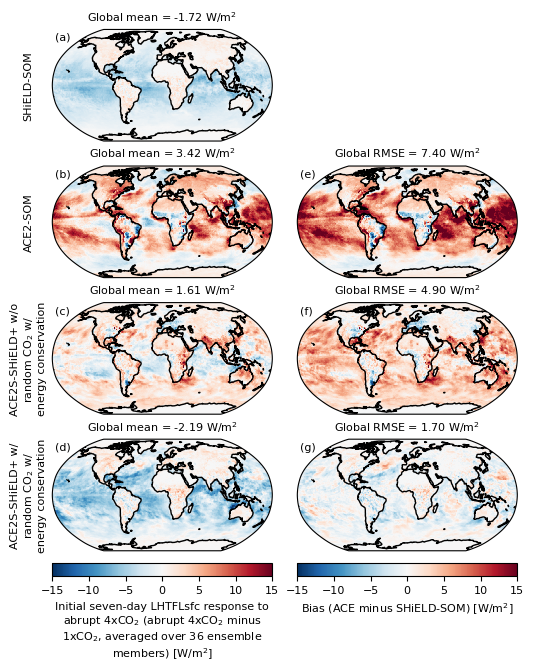

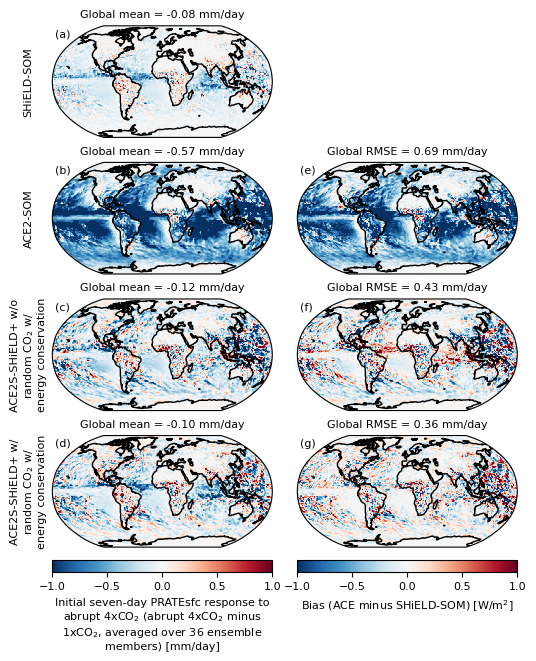

In [20]:
SECONDS_PER_DAY = 86400

plot_response(response, MODELS, "USWRFtoa", "USWRFtoa", "W/m$^2$", scale_factor=1.0, vmin=-15, vmax=15)
plot_response(response, MODELS, "ULWRFtoa", "ULWRFtoa", "W/m$^2$", scale_factor=1.0, vmin=-15, vmax=15)
plot_response(response, MODELS, "LHTFLsfc", "LHTFLsfc", "W/m$^2$", scale_factor=1.0, vmin=-15, vmax=15)
plot_response(response, MODELS, "PRATEsfc", "PRATEsfc", "mm/day", scale_factor=SECONDS_PER_DAY, vmin=-1, vmax=1)